In [1]:
!pip install -q dagshub mlflow

import os
import dagshub
import mlflow
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
DAGSHUB_TOKEN = user_secrets.get_secret("DAGSHUB_TOKEN")
DAGSHUB_USERNAME = user_secrets.get_secret("DAGSHUB_USERNAME")

REPO_NAME = "ML_assignment1"

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

dagshub.init(
    repo_name=REPO_NAME,
    repo_owner=DAGSHUB_USERNAME,
    mlflow=True
)

mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USERNAME}/{REPO_NAME}.mlflow")

print("Connected")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.1 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 6.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 61.7 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=215899bb-5b0f-4f37-9bec-2837a57370a6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=23c1992da0205e5de6e40decb54d2819cd0f9bc2bede72cf50988d89c3b4560e




Accessing as njvar23

Initialized MLflow to track repo "njvar23/ML_assignment1"

Repository njvar23/ML_assignment1 initialized!

Connected


In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

missing_pr = train_df.isnull().sum() / len(train_df)
cols_to_drop = missing_pr[missing_pr > 0.4].index.tolist()
if 'Id' in train_df.columns:
    cols_to_drop.append('Id')
df_cleaned = train_df.drop(columns=cols_to_drop)

X = df_cleaned.drop(columns=['SalePrice'])
y = df_cleaned['SalePrice']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

for col in cat_cols:
    X_train[col] = X_train[col].fillna("None")
    X_val[col] = X_val[col].fillna("None")

for col in num_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)

X_train_enc = pd.get_dummies(X_train)
X_val_enc = pd.get_dummies(X_val)
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"Alignment complete. Columns in model: {len(X_train_enc.columns)}")

model_name = "HousePrice_Best_Model"
model_version = 4 

model_uri = f"models:/{model_name}/{model_version}"
loaded_model = mlflow.sklearn.load_model(model_uri)

print(f"Model {model_name} version {model_version} loaded successfully!")

Alignment complete. Columns in model: 274


Model HousePrice_Best_Model version 4 loaded successfully!


--- Model Inference Results ---
   Actual Price  Predicted Price    Difference
0        154500    154441.346272     58.653728
1        325000    349348.349951 -24348.349951
2        115000     98190.184197  16809.815803
3        159000    168552.972482  -9552.972482
4        315500    331567.938452 -16067.938452
5         75500     66016.651533   9483.348467
6        311500    234097.247196  77402.752804
7        146000    137797.118797   8202.881203
8         84500     60128.749943  24371.250057
9        135500    147118.839077 -11618.839077


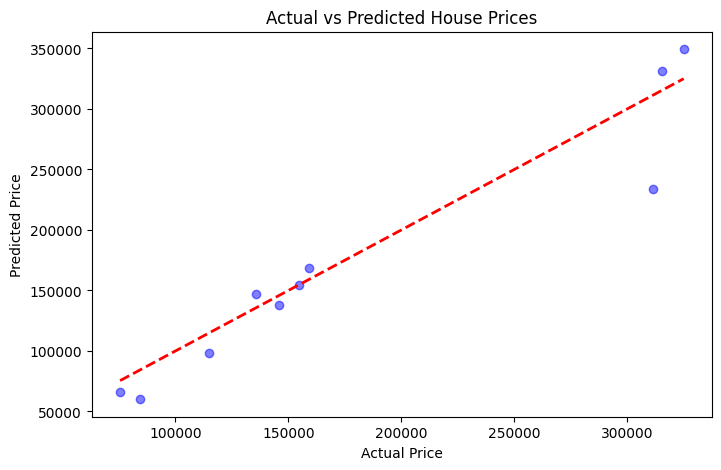

In [3]:
sample_data = X_val_enc.head(10)
actual_prices = y_val.head(10).values

predicted_prices = loaded_model.predict(sample_data)

results_df = pd.DataFrame({
    'Actual Price': actual_prices,
    'Predicted Price': predicted_prices,
    'Difference': actual_prices - predicted_prices
})

print("--- Model Inference Results ---")
print(results_df)

plt.figure(figsize=(8, 5))
plt.scatter(actual_prices, predicted_prices, color='blue', alpha=0.5)
plt.plot([actual_prices.min(), actual_prices.max()], [actual_prices.min(), actual_prices.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [4]:
test_data_raw = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')
test_ids = test_data_raw['Id']

test_data_dropped = test_data_raw.drop(columns=[c for c in cols_to_drop if c in test_data_raw.columns])

for col in cat_cols:
    test_data_dropped[col] = test_data_dropped[col].fillna("None")
for col in num_cols:
    test_data_dropped[col] = test_data_dropped[col].fillna(X_train[col].median())

test_enc = pd.get_dummies(test_data_dropped)
test_final = test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

final_predictions = loaded_model.predict(test_final)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully!")

Submission file 'submission.csv' created successfully!
